# Ejercicio 7. Construcción de indicadores y visualización

Indicadores de los viajes de taxi con los datos de 2024 y 2026. El ejercicio 8 los actualiza con 2025.

In [1]:
import os
import time
from pathlib import Path

import duckdb
import pandas as pd

if Path.cwd().name == "notebooks":
    os.chdir("..")

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
con = duckdb.connect()


def consulta(ruta):
    """Imprime un archivo de sql, lo ejecuta y muestra el tiempo"""
    texto = Path("sql", ruta).read_text(encoding="utf-8")
    print(texto)
    inicio = time.perf_counter()
    resultado = con.execute(texto).df()
    print(f"-- {time.perf_counter() - inicio:.2f} s")
    return resultado

con.execute(Path("sql/vistas.sql").read_text(encoding="utf-8"))

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

COLOR = {"yellow": "#eda100", "green": "#008300"}
NOMBRE = {"yellow": "Amarillo", "green": "Verde"}
COLOR_ANIO = {2024: "#2a78d6", 2025: "#eb6834", 2026: "#1baf7a"}
MESES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e", "axes.titlecolor": "#0b0b0b",
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
    "legend.frameon": False, "legend.fontsize": 9, "figure.dpi": 110, "font.size": 10,
})
miles = FuncFormatter(lambda x, _: f"{x:,.0f}")

def grafica_indicador(datos, titulo, unidad):
    """Dos paneles, amarillo y verde, con una línea por año"""
    fig, ejes = plt.subplots(1, 2, figsize=(10, 3.2))
    for eje, taxi in zip(ejes, ["yellow", "green"]):
        d = datos[datos.taxi == taxi]
        for anio, g in d.groupby(d.periodo.dt.year):
            eje.plot(g.periodo.dt.month, g.valor, color=COLOR_ANIO[anio], label=str(anio), marker="o", markersize=5,
                     markeredgecolor="#fcfcfb", markeredgewidth=1.5)
        eje.set_title(f"Taxi {NOMBRE[taxi].lower()}")
        eje.set_xticks(range(1, 13), MESES)
        eje.set_ylim(0, d.valor.max() * 1.15)
        eje.yaxis.set_major_formatter(miles if d.valor.max() >= 1000 else FuncFormatter(lambda x, _: f"{x:g}"))
    ejes[0].set_ylabel(unidad)
    ejes[0].legend(loc="lower left", ncols=3)
    fig.suptitle(titulo, x=0.01, ha="left", fontweight="bold")
    fig.tight_layout()
    plt.show()


def indicador(archivo, titulo, unidad, mostrar_sql=True):
    ruta = f"indicadores/{archivo}"
    datos = consulta(ruta) if mostrar_sql else con.execute(Path("sql", ruta).read_text(encoding="utf-8")).df()
    datos["periodo"] = pd.to_datetime(datos.periodo)
    tabla = datos.pivot_table(index=datos.periodo.dt.month.rename("mes"),
                              columns=["taxi", datos.periodo.dt.year.rename("anio")], values="valor")
    display(tabla.reindex(columns=["yellow", "green"], level=0))
    grafica_indicador(datos, titulo, unidad)
    return datos

In [2]:
consulta("ej5/01_archivos_por_anio.sql")

-- Archivos, meses y registros por tipo de taxi y año, según el pie de cada Parquet
SELECT
    regexp_extract(file_name, '(yellow|green)_tripdata', 1) AS tipo,
    regexp_extract(file_name, '_(\d{4})-\d{2}\.parquet', 1)::INT AS anio,
    count(*) AS archivos,
    min(regexp_extract(file_name, '(\d{4}-\d{2})\.parquet', 1)) AS primer_mes,
    max(regexp_extract(file_name, '(\d{4}-\d{2})\.parquet', 1)) AS ultimo_mes,
    sum(num_rows)::BIGINT AS registros
FROM parquet_file_metadata('data/raw/*/*/*.parquet')
GROUP BY tipo, anio
ORDER BY tipo DESC, anio

-- 0.03 s


,tipo,anio,archivos,primer_mes,ultimo_mes,registros
0,yellow,2024,12,2024-01,2024-12,41169720
1,yellow,2026,8,2026-01,2026-08,29703355
2,green,2024,12,2024-01,2024-12,660218
3,green,2026,8,2026-01,2026-08,337114


## 7.1 Preguntas

1. ¿Cuántos viajes hay por día y cómo cambia ese número entre meses y años?
2. ¿La demanda sigue el mismo patrón estacional cada año?
3. ¿Cuánto paga un pasajero en un viaje típico y cómo cambia ese monto?
4. ¿Qué parte de los viajes se pide con tarifa fija por aplicación (Flex Fare)?
5. ¿Se sigue usando el efectivo?
6. ¿Cuánta propina deja quien paga con tarjeta?
7. ¿A cuántos viajes alcanza el cobro por entrar a la zona de congestión de Manhattan?
8. ¿Cambió la velocidad de los viajes dentro de Manhattan?
9. ¿Qué peso tienen los viajes desde o hacia los aeropuertos?
10. ¿Qué parte de los registros de cada mes no sirve para el análisis?

## 7.2 y 7.6 Indicadores y justificación

| Indicador | Preguntas | Cálculo | Por qué |
| --- | --- | --- | --- |
| I1 Viajes por día | 1 y 2 | Viajes válidos del mes entre sus días | Mide la demanda sin el efecto de meses de 28 o 31 días |
| I2 Total del viaje mediano | 3 | Mediana del total cobrado | La mediana no se mueve con los totales extremos del ejercicio 3 |
| I3 Viajes Flex Fare | 4 | Porcentaje con payment_type 0 o nulo | En 2026 una cuarta parte de los amarillos es Flex Fare (ejercicio 4) |
| I4 Viajes en efectivo | 5 | Porcentaje con payment_type 2 | Muestra el cambio de medio de pago y separa amarillos de verdes |
| I5 Propina con tarjeta | 6 | Promedio de la propina entre la tarifa en pagos con tarjeta | La propina se registra con tarjeta y no con efectivo (ejercicio 4) |
| I6 Viajes con cargo CBD | 7 | Porcentaje con cbd_congestion_fee mayor a 0 | El cargo empezó en enero de 2025 y cambia el total del viaje |
| I7 Velocidad en Manhattan | 8 | Mediana de millas por hora de los viajes que empiezan y terminan en Manhattan | La congestión se refleja en la velocidad, y el cobro de 2025 busca reducirla |
| I8 Viajes de aeropuerto | 9 | Porcentaje que empieza o termina en Newark, JFK o LaGuardia | Los aeropuertos explican la mitad de los totales atípicos (ejercicio 4) |
| I9 Registros excluidos | 10 | Porcentaje de registros fuera de viajes_validos | Muestra si la calidad de los datos cambia entre meses |

## 7.3, 7.4 y 7.7 Consultas y visualizaciones

Cada indicador sale de un archivo de sql/indicadores que usa las vistas de sql/vistas.sql. Las gráficas usan un panel por tipo de taxi, porque los amarillos tienen 80 veces más viajes, y una línea por año para comparar el mismo mes.

### I1 Viajes por día

-- I1 Viajes válidos por día en cada mes
SELECT
    periodo,
    taxi,
    round(count(*) / day(last_day(periodo))) AS valor
FROM viajes_validos
GROUP BY periodo, taxi
ORDER BY taxi DESC, periodo



-- 0.72 s


taxi    yellow             green        
anio      2024      2026    2024    2026
mes                                     
1      92478.0  113401.0  1713.0  1244.0
2      99959.0  114619.0  1733.0  1271.0
3     110873.0  121346.0  1739.0  1365.0
4     113711.0  122437.0  1759.0  1405.0
5     116606.0  126158.0  1848.0  1382.0
6     114179.0  121515.0  1716.0  1407.0
7      95842.0  107907.0  1558.0  1264.0
8      92403.0  102022.0  1562.0  1243.0
9     116040.0       NaN  1701.0     NaN
10    118681.0       NaN  1709.0     NaN
11    116906.0       NaN  1630.0     NaN
12    113422.0       NaN  1626.0     NaN

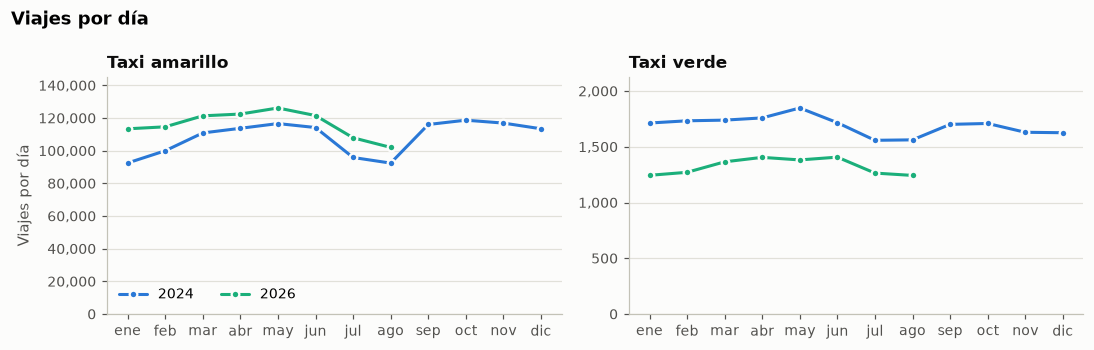

In [3]:
i1 = indicador("01_viajes_por_dia.sql", "Viajes por día", "Viajes por día")

Los amarillos tienen más viajes por día en cada mes de 2026 que en el mismo mes de 2024, entre 6% y 23% más, mientras los verdes tienen entre 18% y 27% menos. Los dos años siguen la misma forma. La demanda sube hasta mayo y cae en julio y agosto, y en 2024 se recupera en septiembre.

### I2 Total del viaje mediano

-- I2 Total cobrado en el viaje mediano, en dólares
SELECT
    periodo,
    taxi,
    round(median(total_amount), 2) AS valor
FROM viajes_validos
GROUP BY periodo, taxi
ORDER BY taxi DESC, periodo



-- 1.44 s


taxi yellow         green       
anio   2024   2026   2024   2026
mes                             
1     20.16  23.10  18.34  20.10
2     20.41  24.00  18.40  20.12
3     20.64  23.35  18.48  20.46
4     21.00  23.58  18.85  20.46
5     21.60  23.93  19.80  20.81
6     21.35  23.84  19.65  20.95
7     21.00  23.58  19.53  20.70
8     21.00  23.55  19.85  20.90
9     21.84    NaN  20.30    NaN
10    21.84    NaN  19.75    NaN
11    21.36    NaN  19.32    NaN
12    21.85    NaN  19.15    NaN

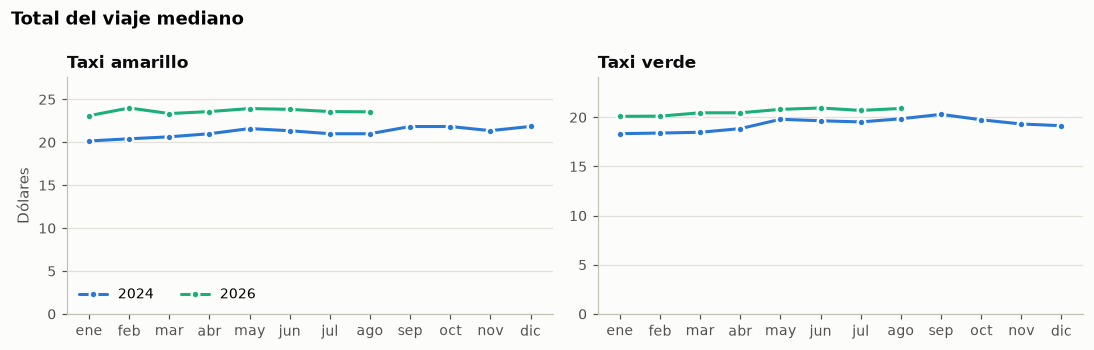

In [4]:
i2 = indicador("02_total_mediano.sql", "Total del viaje mediano", "Dólares")

El viaje amarillo mediano cuesta entre 2.33 y 3.59 dólares más que en el mismo mes de 2024. En enero pasó de 20.16 a 23.10 dólares y en agosto de 21.00 a 23.55. En verdes la diferencia va de 1.01 a 1.98 dólares. Parte del aumento en amarillos es el cargo CBD de 0.75 dólares, que no existía en 2024 (I6).

### I3 Viajes Flex Fare

-- I3 Porcentaje de viajes Flex Fare (payment_type 0 en amarillos, nulo en verdes)
SELECT
    periodo,
    taxi,
    round(100 * avg((coalesce(payment_type, 0) = 0)::INT), 1) AS valor
FROM viajes_validos
GROUP BY periodo, taxi
ORDER BY taxi DESC, periodo



-- 0.75 s


taxi yellow       green      
anio   2024  2026  2024  2026
mes                          
1       4.0  28.3   6.1  13.7
2       5.1  28.9   5.6  14.7
3      10.6  22.9   3.8  15.5
4      11.4  20.2   3.7  14.7
5      10.7  22.5   3.2  12.9
6      11.3  25.3   3.5  15.0
7       8.9  26.2   3.2  15.7
8       8.3  26.5   3.2  15.5
9      12.4   NaN   3.2   NaN
10      9.4   NaN   3.0   NaN
11      9.6   NaN   3.1   NaN
12      8.2   NaN   3.8   NaN

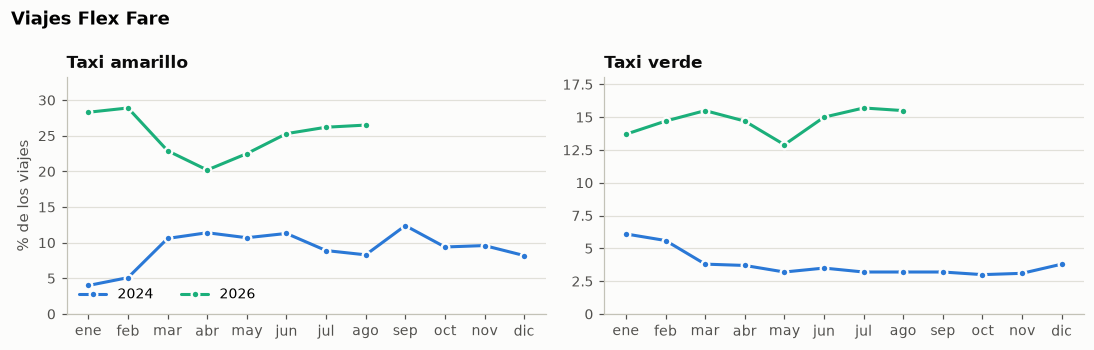

In [5]:
i3 = indicador("03_flex_fare.sql", "Viajes Flex Fare", "% de los viajes")

De enero a agosto, Flex Fare pasó de entre el 4.0% y el 11.4% de los viajes amarillos en 2024 a entre el 20.2% y el 28.9% en 2026. En verdes subió de entre el 3.2% y el 6.1% a entre el 12.9% y el 15.7%. Es el cambio más grande entre los dos años.

### I4 Viajes pagados en efectivo

-- I4 Porcentaje de viajes pagados en efectivo
SELECT
    periodo,
    taxi,
    round(100 * avg((coalesce(payment_type, 0) = 2)::INT), 1) AS valor
FROM viajes_validos
GROUP BY periodo, taxi
ORDER BY taxi DESC, periodo



-- 0.74 s


taxi yellow      green      
anio   2024 2026  2024  2026
mes                         
1      14.7  8.3  28.6  20.6
2      13.7  8.0  28.0  20.0
3      13.3  8.9  29.6  19.3
4      13.2  9.3  27.1  19.0
5      13.3  9.0  27.2  19.7
6      13.1  9.3  27.0  19.0
7      14.6  9.8  27.3  18.2
8      14.9  9.9  27.1  19.6
9      12.1  NaN  26.0   NaN
10     12.3  NaN  25.7   NaN
11     12.1  NaN  25.3   NaN
12     13.2  NaN  25.6   NaN

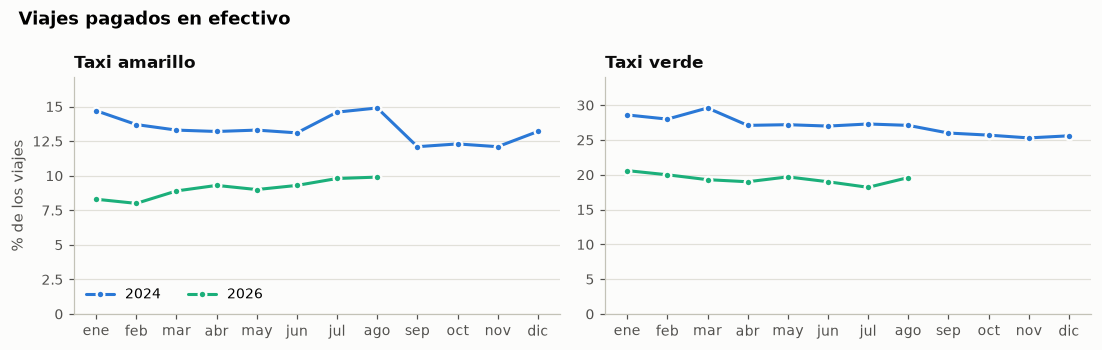

In [6]:
i4 = indicador("04_efectivo.sql", "Viajes pagados en efectivo", "% de los viajes")

El efectivo bajó en los dos tipos. De enero a agosto, en amarillos pasó de entre el 13.1% y el 14.9% de los viajes a entre el 8.0% y el 9.9%, y en verdes de entre el 27.0% y el 29.6% a entre el 18.2% y el 20.6%. La caída del efectivo acompaña el crecimiento de Flex Fare.

### I5 Propina con tarjeta

-- I5 Propina promedio como porcentaje de la tarifa en viajes pagados con tarjeta
SELECT
    periodo,
    taxi,
    round(100 * avg(tip_amount / fare_amount), 1) AS valor
FROM viajes_validos
WHERE payment_type = 1 AND fare_amount > 0
GROUP BY periodo, taxi
ORDER BY taxi DESC, periodo



-- 0.60 s


taxi yellow       green      
anio   2024  2026  2024  2026
mes                          
1      26.3  25.0  22.8  23.1
2      25.4  24.8  22.5  23.0
3      25.2  24.8  22.4  23.1
4      25.5  25.0  22.5  23.3
5      24.9  24.5  22.3  22.7
6      24.7  26.4  22.1  22.6
7      25.1  25.2  22.4  23.0
8      24.7  25.0  22.2  23.0
9      24.4   NaN  22.1   NaN
10     24.7   NaN  22.2   NaN
11     26.3   NaN  22.4   NaN
12     24.9   NaN  22.6   NaN

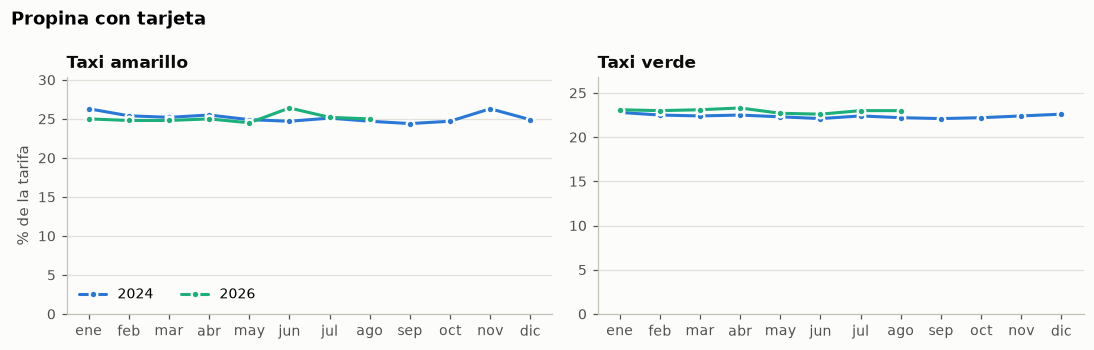

In [7]:
i5 = indicador("05_propina_tarjeta.sql", "Propina con tarjeta", "% de la tarifa")

La propina con tarjeta se mantiene entre el 24.4% y el 26.4% de la tarifa en amarillos y entre el 22.1% y el 23.3% en verdes, sin diferencia clara entre años.

### I6 Viajes con cargo CBD

-- I6 Porcentaje de viajes que pagan el cargo de la zona de congestión de Manhattan (CBD)
SELECT
    periodo,
    taxi,
    round(100 * avg((cbd_congestion_fee > 0)::INT), 1) AS valor
FROM viajes_validos
GROUP BY periodo, taxi
ORDER BY taxi DESC, periodo



-- 0.65 s


taxi yellow       green     
anio   2024  2026  2024 2026
mes                         
1       0.0  70.9   0.0  7.9
2       0.0  71.0   0.0  7.1
3       0.0  71.5   0.0  8.1
4       0.0  71.8   0.0  8.4
5       0.0  66.8   0.0  8.9
6       0.0  74.2   0.0  8.5
7       0.0  77.2   0.0  9.2
8       0.0  77.1   0.0  9.8
9       0.0   NaN   0.0  NaN
10      0.0   NaN   0.0  NaN
11      0.0   NaN   0.0  NaN
12      0.0   NaN   0.0  NaN

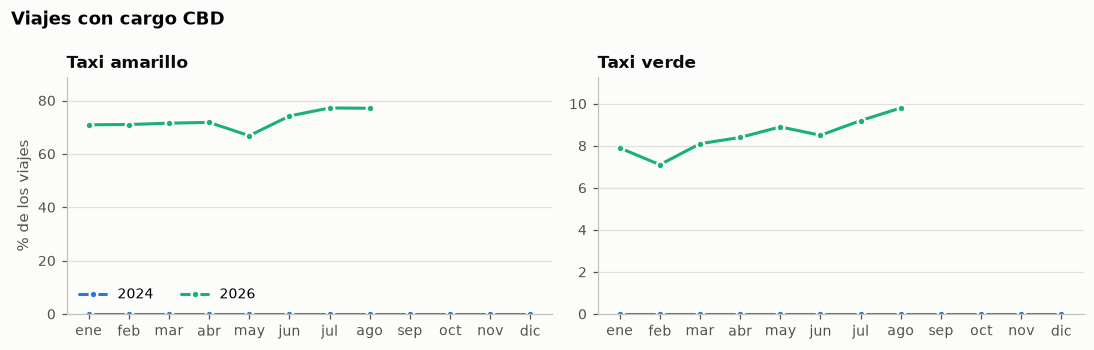

In [8]:
i6 = indicador("06_cargo_cbd.sql", "Viajes con cargo CBD", "% de los viajes")

En 2024 ningún viaje paga el cargo CBD, porque el cobro empezó en enero de 2025. En 2026 lo paga entre el 66.8% y el 77.2% de los viajes amarillos, con los valores más altos en julio y agosto, y entre el 7.1% y el 9.8% de los verdes, que trabajan sobre todo fuera de la zona de cobro.

### I7 Velocidad dentro de Manhattan

-- I7 Velocidad mediana, en millas por hora, de los viajes que empiezan y terminan en Manhattan
SELECT
    v.periodo,
    v.taxi,
    round(median(v.trip_distance / (v.duracion_min / 60)), 2) AS valor
FROM viajes_validos AS v
JOIN zonas AS inicio ON v.PULocationID = inicio.zona_id
JOIN zonas AS fin ON v.DOLocationID = fin.zona_id
WHERE inicio.distrito = 'Manhattan' AND fin.distrito = 'Manhattan'
GROUP BY v.periodo, v.taxi
ORDER BY v.taxi DESC, v.periodo



-- 1.39 s


taxi yellow        green       
anio   2024  2026   2024   2026
mes                            
1      9.05  8.69  10.18   9.47
2      8.89  8.24  10.20   9.10
3      8.96  8.74  10.12   9.85
4      8.81  8.34  10.10   9.85
5      8.48  8.21   9.69   9.52
6      8.75  8.37   9.99   9.57
7      8.91  8.66  10.45  10.09
8      8.93  8.88  10.44  10.12
9      8.28   NaN   9.74    NaN
10     8.12   NaN   9.81    NaN
11     8.18   NaN   9.78    NaN
12     7.95   NaN   9.98    NaN

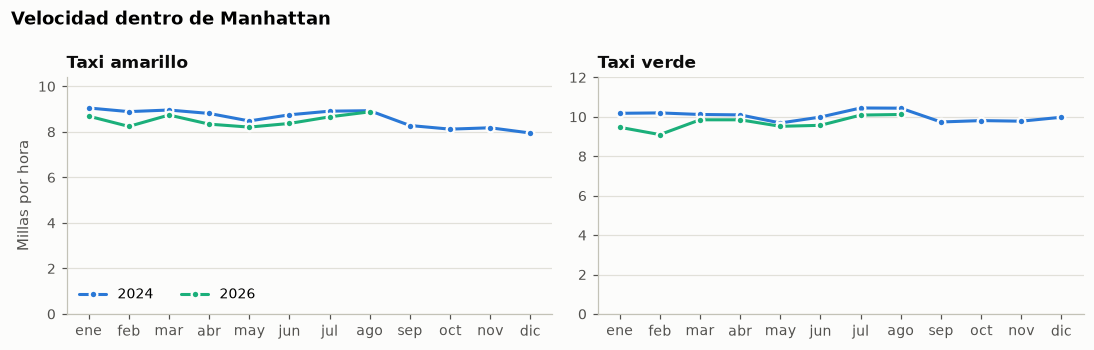

In [9]:
i7 = indicador("07_velocidad_manhattan.sql", "Velocidad dentro de Manhattan", "Millas por hora")

La velocidad mediana dentro de Manhattan es menor en 2026 que en 2024 en todos los meses de enero a agosto. En amarillos va de 8.21 a 8.88 millas por hora en 2026 contra 8.48 a 9.05 en 2024, y en verdes de 9.10 a 10.12 contra 9.69 a 10.45. En 2026 no se ven viajes más rápidos que antes del cobro por congestión. El ejercicio 8 agrega 2025, el primer año del cobro.

### I8 Viajes de aeropuerto

-- I8 Porcentaje de viajes que empiezan o terminan en Newark (1), JFK (132) o LaGuardia (138)
SELECT
    periodo,
    taxi,
    round(100 * avg((PULocationID IN (1, 132, 138) OR DOLocationID IN (1, 132, 138))::INT), 1) AS valor
FROM viajes_validos
GROUP BY periodo, taxi
ORDER BY taxi DESC, periodo



-- 0.75 s


taxi yellow      green     
anio   2024 2026  2024 2026
mes                        
1       9.8  7.7   3.2  2.8
2       9.1  7.3   3.5  3.1
3       9.5  8.0   4.0  3.4
4       9.7  8.1   4.2  3.2
5      10.2  8.0   4.8  3.7
6      10.0  8.4   4.3  3.5
7      11.3  8.7   4.3  3.5
8      11.8  9.2   5.0  3.6
9      10.4  NaN   4.8  NaN
10     10.4  NaN   4.5  NaN
11      9.4  NaN   4.1  NaN
12      9.8  NaN   3.9  NaN

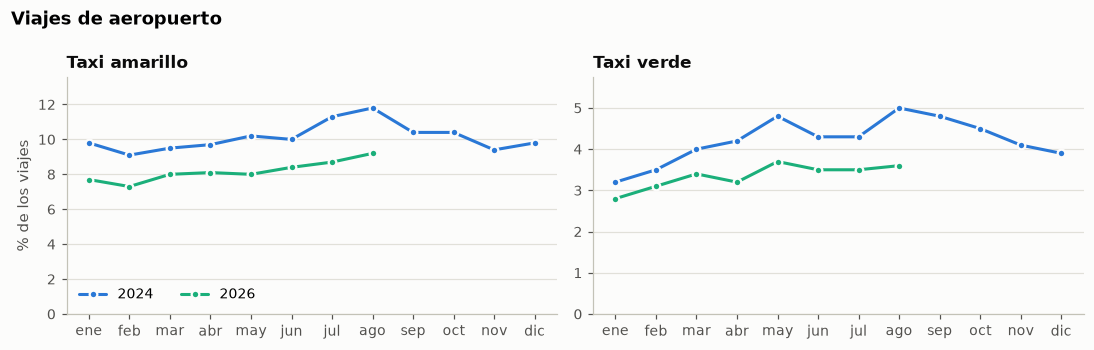

In [10]:
i8 = indicador("08_aeropuertos.sql", "Viajes de aeropuerto", "% de los viajes")

Los viajes de aeropuerto pesan menos en 2026. De enero a agosto son entre el 7.3% y el 9.2% de los amarillos, contra el 9.1% a 11.8% de 2024, y entre el 2.8% y el 3.7% de los verdes, contra el 3.2% a 5.0%.

### I9 Registros excluidos por calidad

-- I9 Porcentaje de registros que no pasan las reglas de calidad de viajes_validos
WITH registros AS (
    SELECT periodo, taxi, count(*) AS total
    FROM viajes
    GROUP BY periodo, taxi
),
validos AS (
    SELECT periodo, taxi, count(*) AS validos
    FROM viajes_validos
    GROUP BY periodo, taxi
)
SELECT
    periodo,
    taxi,
    round(100 * (1 - validos / total), 2) AS valor
FROM registros
JOIN validos USING (periodo, taxi)
ORDER BY taxi DESC, periodo



-- 0.69 s


taxi yellow       green      
anio   2024  2026  2024  2026
mes                          
1      3.30  5.62  6.07  4.24
2      3.61  5.60  6.22  4.80
3      4.06  4.83  6.16  4.28
4      2.93  4.13  6.55  4.73
5      2.93  4.40  6.11  4.66
6      3.22  5.00  5.95  4.40
7      3.44  5.24  6.81  4.98
8      3.85  5.22  6.48  5.26
9      4.18   NaN  6.24   NaN
10     4.03   NaN  5.64   NaN
11     3.82   NaN  6.36   NaN
12     4.15   NaN  6.63   NaN

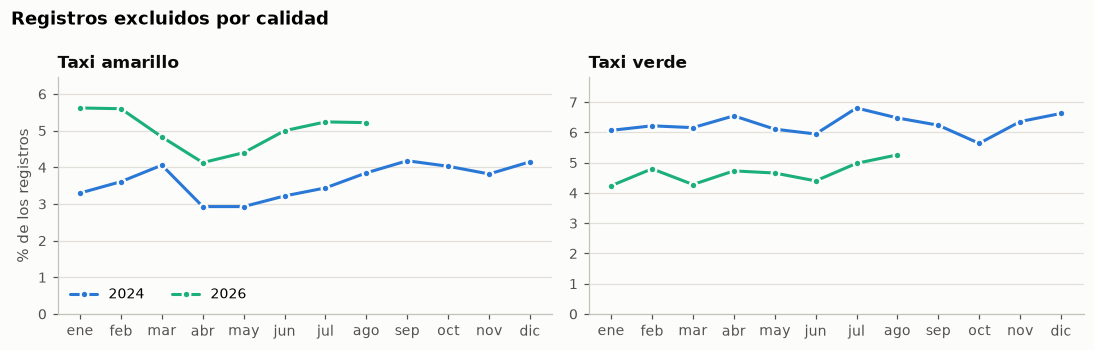

In [11]:
i9 = indicador("09_registros_excluidos.sql", "Registros excluidos por calidad", "% de los registros")

De enero a agosto, en amarillos se excluye entre el 4.1% y el 5.6% de los registros de 2026, contra el 2.9% a 4.1% de 2024. En verdes ocurre lo contrario, del 6.0% a 6.8% en 2024 al 4.2% a 5.3% en 2026. La calidad de los datos cambia entre años, así que vale la pena seguirla cada mes.

## 7.5 Tablero

El tablero está en Metabase, la herramienta de visualización del ambiente (servicio metabase, http://localhost:3000). El script scripts/tablero_metabase.py ejecuta las nueve consultas de sql/indicadores y guarda sus resultados como tablas en data/processed/tablero.duckdb, porque un tablero repite las mismas consultas en cada visita y el ejercicio 6 mostró que conviene materializarlas. Después, con la API de Metabase, conecta esa base sin permiso de escritura y crea una pregunta por indicador, el filtro por tipo de taxi y el tablero, con la pregunta y la interpretación de cada indicador debajo de su gráfica.

```bash
docker compose up -d
docker compose exec lab python scripts/tablero_metabase.py
```

Captura del tablero con 2024 y 2026.

![Tablero con 2024 y 2026](../docs/evidencias/07_tablero_2024_2026.png)

## 7.8 Interpretación y hallazgos

1. Los taxis amarillos ganaron viajes y los verdes los perdieron. Cada mes de 2026 tiene entre 6% y 23% más viajes amarillos por día que el mismo mes de 2024, y entre 18% y 27% menos viajes verdes.
2. La forma de pagar cambió. Flex Fare pasó de entre el 4% y el 11% de los viajes amarillos a entre el 20% y el 29%, y el efectivo bajó de cerca del 14% a cerca del 9%.
3. El viaje amarillo mediano cuesta entre 2.33 y 3.59 dólares más, y el cargo CBD aparece en cerca del 72% de los viajes amarillos de 2026.
4. Los viajes dentro de Manhattan no van más rápido con el cobro por congestión. La velocidad mediana de 2026 es menor que la de 2024 en todos los meses comparables.
5. La propina con tarjeta se mantiene alrededor del 25% de la tarifa en amarillos y del 23% en verdes.

Con dos años separados por uno sin datos no se sabe si estos cambios ocurrieron de golpe o poco a poco. El ejercicio 8 lo revisa con 2025.